In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
import pandas as pd
import scanpy as sc
import anndata
import scipy
import pickle 

%matplotlib inline

# Load your data

In [2]:
rna = sc.read('rna_crc.h5ad')

In [3]:
rna

AnnData object with n_obs × n_vars = 6486 × 772
    obs: 'sample'
    obsm: 'X_pca'
    obsp: 'connectivities'

In [4]:
get_X = scipy.sparse.load_npz('get_X.npz')
get = sc.read('get_sub.h5ad')

get.X = get_X

In [5]:
get

AnnData object with n_obs × n_vars = 4000 × 57094
    obs: 'batch'
    obsm: 'X_ttd'
    obsp: 'connectivities'

# Global training

In [7]:
from mowgan.train import MOWGAN

In [8]:
# 1. Initialize trainer
trainer = MOWGAN(data=[rna, get],
                     query=['X_pca','X_ttd'],                     
                     save_name=['rna','get'],
                     n_dim=20,
                     fill=[128,128],
                     n_epochs=10,
                     path="./my_directory",
                     mode='global') #default

In [9]:
# 2. Preprocess batches
trainer.preprocess_batches()

In [10]:
# 3. Build WGAN
trainer.build_model()

In [11]:
# 4. Train and generate synthetic samples
trainer.train()

✅ Saved scalers for global -> ./my_directory/scalers.pkl


2026-02-03 15:37:40.424273: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-03 15:37:40.463912: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-03 15:37:40.542715: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 00000 | D_loss: 6.0770 | G_loss: 0.0066


2026-02-03 15:37:40.690550: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


📉 Saved loss history -> ./my_directory/loss_history.pkl
✅ Saved generated data: rna.h5ad
✅ Saved generated data: get.h5ad


In [14]:
# 5. Load the generated data
rna_MOWGAN = sc.read('./my_directory/rna.h5ad')
get_MOWGAN = sc.read('./my_directory/get.h5ad')

In [15]:
rna_MOWGAN

AnnData object with n_obs × n_vars = 5000 × 772
    obsm: 'X_pca'

In [16]:
get_MOWGAN

AnnData object with n_obs × n_vars = 5000 × 57094
    obsm: 'X_ttd'

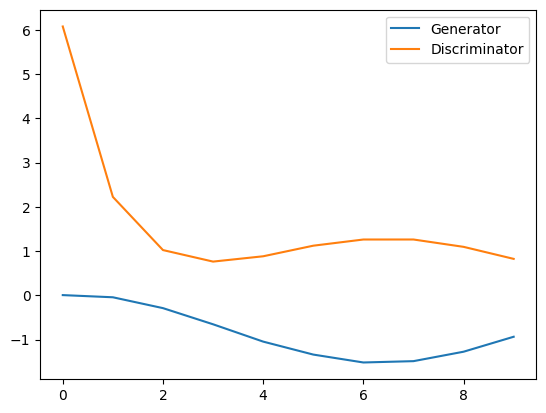

In [17]:
with open("./my_directory/loss_history.pkl", "rb") as f:
    history = pickle.load(f)

plt.plot(history["gen_loss"], label="Generator")
plt.plot(history["disc_loss"], label="Discriminator")
plt.legend()
plt.show()

### Additional data

In [18]:
# 6. To generate new samples from a saved model, we need to initialize the class, 
#    build the model architecture, and load the previously saved weights.

trainer = MOWGAN(data=[rna, get],
                     query=['X_pca','X_ttd'],                     
                     save_name=['rna_new','get_new'],  # different names compare to before, so to not overwrite
                     n_dim=20,
                     fill=[128,128],
                     n_epochs=100,
                     path="./my_directory")

trainer.build_model()

trainer.generate_and_construct_anndata(n_samples=12134)

✅ Loaded generator & discriminator weights for global
✅ Loaded scalers for global from ./my_directory/scalers.pkl
✅ Saved generated data: rna_new.h5ad
✅ Saved generated data: get_new.h5ad


In [19]:
new_rna = sc.read('my_directory/rna.h5ad')
new_rna

AnnData object with n_obs × n_vars = 5000 × 772
    obsm: 'X_pca'

In [20]:
new_get = sc.read('my_directory/get.h5ad')
new_get

AnnData object with n_obs × n_vars = 5000 × 57094
    obsm: 'X_ttd'

# Batch

In [21]:
# 1. Initialize trainer
trainer = MOWGAN(data=[rna, get],
                     query=['X_pca','X_ttd'],                     
                     save_name=['rna','get'],
                     batch=['sample','batch'],
                     mode = 'batch',
                     n_dim=20,
                     fill=[128,128],
                     n_epochs=10,
                     path="./my_directory")

In [22]:
# 2. Preprocess batches
trainer.preprocess_batches()

In [23]:
# 3. Build WGAN
trainer.build_model()

In [24]:
# 4. Train and generate synthetic samples
trainer.train()


⚡ Training batch 0
✅ Saved scalers for batch 0 -> ./my_directory/scalers_batch_0.pkl
Epoch 00000 | D_loss: 5.2782 | G_loss: 0.0887


2026-02-03 15:48:44.832141: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


📉 Saved loss history -> ./my_directory/loss_history_batch_0.pkl
✅ Saved generated data: anndata0_0.h5ad
✅ Saved generated data: anndata1_0.h5ad

⚡ Training batch 1
✅ Saved scalers for batch 1 -> ./my_directory/scalers_batch_1.pkl
Epoch 00000 | D_loss: -0.3696 | G_loss: 0.4886
📉 Saved loss history -> ./my_directory/loss_history_batch_1.pkl
✅ Saved generated data: anndata0_1.h5ad
✅ Saved generated data: anndata1_1.h5ad

⚡ Training batch 2
✅ Saved scalers for batch 2 -> ./my_directory/scalers_batch_2.pkl
Epoch 00000 | D_loss: -0.5655 | G_loss: 0.8023


2026-02-03 15:54:07.731045: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


📉 Saved loss history -> ./my_directory/loss_history_batch_2.pkl
✅ Saved generated data: anndata0_2.h5ad
✅ Saved generated data: anndata1_2.h5ad


In [25]:
# 5. Merge generated batch data to a single AnnData per modality
trainer.merge_batches()

/Users/giansanti.valentina/miniforge3/envs/my_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


✅ Merged 3 batches for dataset 0


/Users/giansanti.valentina/miniforge3/envs/my_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


✅ Merged 3 batches for dataset 1


In [26]:
# 6. Load the generated data
rna_MOWGAN = sc.read('./my_directory/rna.h5ad')
get_MOWGAN = sc.read('./my_directory/get.h5ad')

/Users/giansanti.valentina/miniforge3/envs/my_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/giansanti.valentina/miniforge3/envs/my_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [27]:
rna_MOWGAN

AnnData object with n_obs × n_vars = 15000 × 772
    obs: 'batch'
    obsm: 'X_pca'

In [28]:
get_MOWGAN

AnnData object with n_obs × n_vars = 15000 × 57094
    obs: 'batch'
    obsm: 'X_ttd'

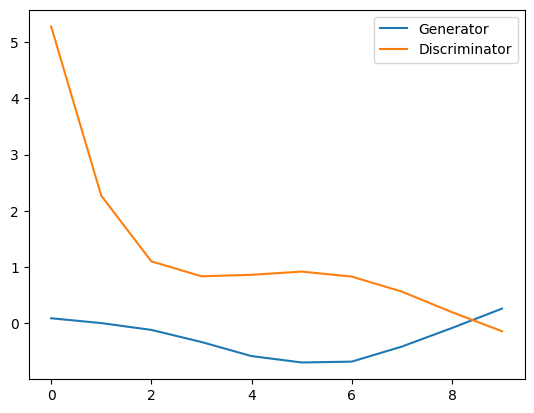

In [29]:
with open("./my_directory/loss_history_batch_0.pkl", "rb") as f:
    history = pickle.load(f)

plt.plot(history["gen_loss"], label="Generator")
plt.plot(history["disc_loss"], label="Discriminator")
plt.legend()
plt.show()


### Additional data

In [30]:
# 7. To generate new samples from a saved model, we need to initialize the class, 
#    build the model architecture, and load the previously saved weights.

trainer = MOWGAN(data=[rna, get],
                     query=['X_pca','X_ttd'],                     
                     save_name=['rna_new','get_new'], # Different names!!!
                     batch=['sample','batch'],
                     mode = 'batch',
                     n_dim=20,
                     fill=[128,128],
                     n_epochs=10,
                     path="./my_directory")

trainer.build_model()

trainer.generate_and_construct_anndata(n_samples=2000, batch_idx=0)
trainer.generate_and_construct_anndata(n_samples=2000, batch_idx=1)
trainer.generate_and_construct_anndata(n_samples=2000, batch_idx=2)

✅ Loaded generator & discriminator weights for batch 0
✅ Loaded scalers for batch 0 from ./my_directory/scalers_batch_0.pkl
✅ Saved generated data: anndata0_0.h5ad
✅ Saved generated data: anndata1_0.h5ad
✅ Loaded generator & discriminator weights for batch 1
✅ Loaded scalers for batch 1 from ./my_directory/scalers_batch_1.pkl
✅ Saved generated data: anndata0_1.h5ad
✅ Saved generated data: anndata1_1.h5ad
✅ Loaded generator & discriminator weights for batch 2
✅ Loaded scalers for batch 2 from ./my_directory/scalers_batch_2.pkl
✅ Saved generated data: anndata0_2.h5ad
✅ Saved generated data: anndata1_2.h5ad


In [31]:
# 8. Merge the new data
trainer.merge_batches()

/Users/giansanti.valentina/miniforge3/envs/my_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


✅ Merged 3 batches for dataset 0


/Users/giansanti.valentina/miniforge3/envs/my_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


✅ Merged 3 batches for dataset 1


In [32]:
rna_new = sc.read('my_directory/rna_new.h5ad')
rna_new

/Users/giansanti.valentina/miniforge3/envs/my_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 6000 × 772
    obs: 'batch'
    obsm: 'X_pca'

In [33]:
rna_new.obs['batch'].value_counts()

batch
0    2000
1    2000
2    2000
Name: count, dtype: int64

In [34]:
get_new = sc.read('my_directory/get_new.h5ad')
get_new

/Users/giansanti.valentina/miniforge3/envs/my_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1806: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 6000 × 57094
    obs: 'batch'
    obsm: 'X_ttd'

In [35]:
get_new.obs['batch'].value_counts()

batch
0    2000
1    2000
2    2000
Name: count, dtype: int64